In [16]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Training data
# [Study Hours, Attendance]
X = np.array([
    [1,50],
    [2,55],
    [3,60],
    [5,75],
    [6,80],
    [7,85],
])

# Target
# 0 = Fail, 1 = Pass
y = np.array([0, 0, 0, 1, 1, 1])

# Create Perceptron model
model = Perceptron(max_iter=1000, random_state=42)

# Train the model
model.fit(X, y)

# Predctions
y_pred = model.predict(X)

# Display results
print("Actual Values: ",y)
print("Predicted Values: ",y_pred)

# Accuracy
accuracy = accuracy_score(y, y_pred)

print("Accuracy: ", accuracy*100, "%")

# Model parameters
print("\nWeights: ", model.coef_)
print("Bias:", model.intercept_)

# Predict a new student
new_student = np.array([[4,70]])

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("\nNew Student Prediction: PASS")
else:
    print("\nNew Student Prediction: FAIL")

Actual Values:  [0 0 0 1 1 1]
Predicted Values:  [0 0 0 0 0 0]
Accuracy:  50.0 %

Weights:  [[ 38. -15.]]
Bias: [-6.]

New Student Prediction: FAIL


# write a python code to implement perceptron

Actual Values: [0 0 0 1 1 1]
Predicted Values: [0 0 0 1 1 1]
New Student Prediction: PASS


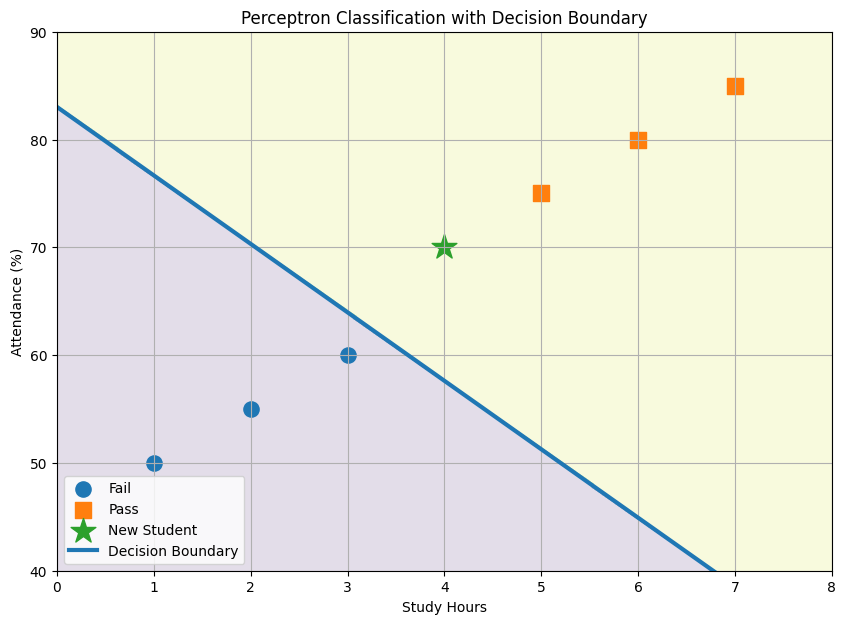

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Study hours, Attendance
X = np.array([
    [1, 50],
    [2, 55],
    [3, 60],
    [5, 75],
    [6, 80],
    [7, 85]
])

# 0 = fail, 1 = pass
y = np.array([0, 0, 0, 1, 1, 1])

# Perceptron with scaling
model = make_pipeline(
    StandardScaler(),
    Perceptron(max_iter=1000, eta0=0.01, random_state=42)
)

model.fit(X, y)

# Predictions
predictions = model.predict(X)

print("Actual Values:", y)
print("Predicted Values:", predictions)

# New Student
new_student = np.array([[4, 70]])

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("New Student Prediction: PASS")
else:
    print("New Student Prediction: FAIL")


# Create grid for visualization
x_min, x_max = 0, 8
y_min, y_max = 40, 90

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(grid)
Z = Z.reshape(xx.shape)

# Visualization
plt.figure(figsize=(10, 7))

# Decision regions
plt.contourf(
    xx, yy, Z, alpha=0.15
)

# Fail points
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    marker='o',
    s=120,
    label='Fail'
)

# Pass points
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker='s',
    s=120,
    label='Pass'
)

# New student
plt.scatter(
    new_student[0, 0],
    new_student[0, 1],
    marker='*',
    s=350,
    label='New Student'
)

# Get scaler and perceptron from pipeline
scaler = model.named_steps['standardscaler']
perceptron = model.named_steps['perceptron']

w = perceptron.coef_[0]
b = perceptron.intercept_[0]

# Convert boundary back to original scale
mean = scaler.mean_
scale = scaler.scale_

w_original = w / scale
b_original = b - np.sum(w * mean / scale)

x_values = np.linspace(0, 8, 100)

y_values = -(
    w_original[0] * x_values + b_original
) / w_original[1]

plt.plot(
    x_values,
    y_values,
    linewidth=3,
    label='Decision Boundary'
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance (%)")
plt.title("Perceptron Classification with Decision Boundary")
plt.legend()
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(40, 90)
plt.show()

Actual Values: [0 0 0 1 1 1]
Predicted Values: [0 0 0 1 1 1]
K = 3
New Student Prediction: PASS

Nearest Neighbors:
Student 4 distance = 5.1 class = pass
Student 3 distance = 10.05 class = fail
Student 5 distance = 10.2 class = pass


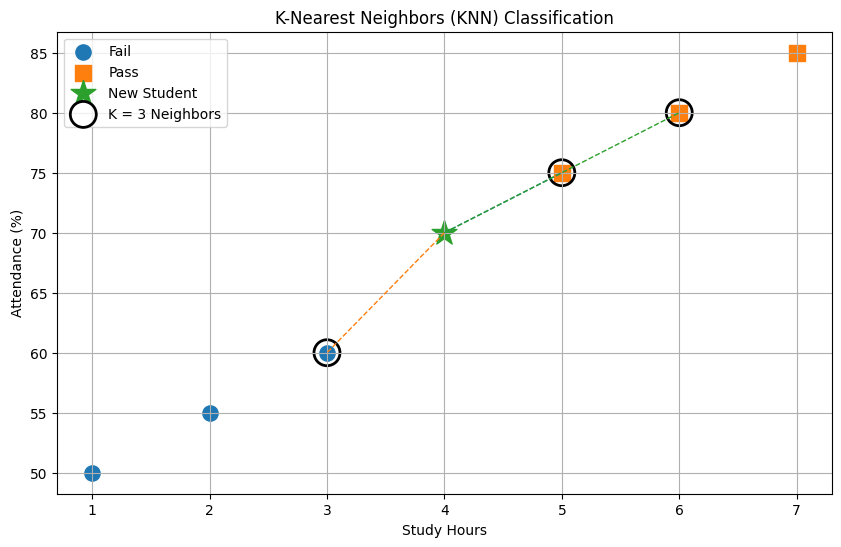

In [18]:
# KNN Classification with Visualization

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Study hours, Attendance
X = np.array([
    [1, 50],
    [2, 55],
    [3, 60],
    [5, 75],
    [6, 80],
    [7, 85]
])

# 0 = fail, 1 = pass
y = np.array([0, 0, 0, 1, 1, 1])

k = 3

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=k)

# Train the model
knn.fit(X, y)

# Predictions
predictions = knn.predict(X)

print("Actual Values:", y)
print("Predicted Values:", predictions)

# New Student
new_student = np.array([[4, 70]])

prediction = knn.predict(new_student)

print("K =", k)

if prediction[0] == 1:
    print("New Student Prediction: PASS")
else:
    print("New Student Prediction: FAIL")

# Finding the nearest neighbors
distances, indices = knn.kneighbors(new_student)

print("\nNearest Neighbors:")

for i in range(k):
    index = indices[0][i]

    print(
        "Student", index + 1,
        "distance =", round(distances[0][i], 2),
        "class =",
        "pass" if y[index] == 1 else "fail"
    )

# Get coordinates of nearest neighbors
nearest = X[indices[0]]

# Visualization
plt.figure(figsize=(10, 6))

# Fail points
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    marker='o',
    s=120,
    label='Fail'
)

# Pass points
plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    marker='s',
    s=120,
    label='Pass'
)

# New student
plt.scatter(
    new_student[0, 0],
    new_student[0, 1],
    marker='*',
    s=350,
    label='New Student'
)

# Nearest neighbors
plt.scatter(
    nearest[:, 0],
    nearest[:, 1],
    facecolors='none',
    edgecolor='black',
    s=350,
    linewidths=2,
    label='K = 3 Neighbors'
)

# Draw lines between new student and neighbors
for point in nearest:
    plt.plot(
        [new_student[0, 0], point[0]],
        [new_student[0, 1], point[1]],
        linestyle='--',
        linewidth=1
    )

plt.xlabel("Study Hours")
plt.ylabel("Attendance (%)")
plt.title("K-Nearest Neighbors (KNN) Classification")

plt.legend()
plt.grid(True)
plt.show()

# what is the class of new student